# Cuaderno de Campo — Pandas & NumPy

**Aarón Martínez Garcidueñas · Big Data, Unidad 1**

Referencia rápida (con ejemplos ejecutables) de las funciones de `pandas` y `numpy` usadas en las prácticas de esta unidad:
- `01_probabilidad_estadistica.ipynb` → crecimiento poblacional (ONU / Our World in Data)
- `02_transformaciones.ipynb` → esperanza de vida al nacer
- `03_fertility_rate.ipynb` → tasa de fertilidad (México, Japón, Brasil)

Cada sección trae: **qué hace la función**, cuándo se usa, y un ejemplo corrido sobre los mismos datasets de las prácticas.

## 00 · Preparación — cargar los tres datasets

Cargamos los tres datasets que usamos en la unidad para que todos los ejemplos de abajo corran con datos reales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# 1) Crecimiento poblacional (dataset local, igual que en 01_probabilidad_estadistica)
df_pop = pd.read_csv("../data/raw/annual-population-growth/annual-population-growth.csv")

# 2) Esperanza de vida al nacer (igual que en 02_transformaciones)
df_le = pd.read_csv(
    "https://ourworldindata.org/grapher/life-expectancy.csv?v=1&csvType=full&useColumnShortNames=true",
    storage_options={"User-Agent": "Our World In Data data fetch/1.0"}
)

# 3) Tasa de fertilidad (igual que en 03_fertility_rate)
df_fert = pd.read_csv(
    "https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true",
    storage_options={"User-Agent": "Our World In Data data fetch/1.0"}
)

print("Población:", df_pop.shape)
print("Esperanza de vida:", df_le.shape)
print("Fertilidad:", df_fert.shape)

Población: (38400, 5)
Esperanza de vida: (21565, 4)
Fertilidad: (19402, 4)


## 01 · Carga y exploración inicial

Lo primero al recibir cualquier dataset: traerlo a memoria y entender su forma.

| Función | Qué hace |
|---|---|
| `pd.read_csv(ruta_o_url)` | Lee un CSV (local o remoto) y lo carga como DataFrame |
| `pd.read_csv(url, storage_options={...})` | Igual, pero mandando cabeceras HTTP (p. ej. `User-Agent`) |
| `df.head(n)` | Primeras `n` filas (5 por defecto) |
| `df.shape` | Tupla `(filas, columnas)` — es atributo, no método |
| `df.columns.tolist()` | Lista con los nombres de las columnas |
| `df.dtypes` | Tipo de dato de cada columna |
| `df.describe()` | Conteo, media, std, min, cuartiles y máx de columnas numéricas |
| `df.isnull().sum()` | Cuenta de valores nulos por columna |
| `df["col"].nunique()` | Número de valores distintos en una columna |

In [2]:
df_pop.head()

,Entity,Code,Year,Annual change in population,Annual population change (Projected)
0,Afghanistan,AFG,1951,103163.0,NaN
1,Afghanistan,AFG,1952,108441.0,NaN
2,Afghanistan,AFG,1953,108919.0,NaN
3,Afghanistan,AFG,1954,111251.0,NaN
4,Afghanistan,AFG,1955,119027.0,NaN


In [3]:
df_pop.shape

(38400, 5)

In [4]:
df_pop.columns.tolist()

['Entity',
 'Code',
 'Year',
 'Annual change in population',
 'Annual population change (Projected)']

In [5]:
df_pop.dtypes

Entity                                      str
Code                                        str
Year                                      int64
Annual change in population             float64
Annual population change (Projected)    float64
dtype: object

In [6]:
df_pop.describe()

,Year,Annual change in population,Annual population change (Projected)
count,38400.000000,1.868800e+04,1.971200e+04
mean,2025.500000,2.063019e+06,8.375481e+05
std,43.300872,9.440859e+06,5.816745e+06
min,1951.000000,-3.315935e+06,-2.291035e+07
25%,1988.000000,1.781000e+03,-9.742750e+03
50%,2025.500000,4.689800e+04,9.350000e+01
75%,2063.000000,3.021128e+05,1.411160e+05
max,2100.000000,9.337137e+07,7.206736e+07


In [7]:
df_pop.isnull().sum()

Entity                                      0
Code                                     1200
Year                                        0
Annual change in population             19712
Annual population change (Projected)    18688
dtype: int64

In [8]:
print(df_pop["Entity"].nunique())  # cuántas entidades/países distintos hay

256


## 02 · Selección e indexación

| Función | Qué hace |
|---|---|
| `df["col"]` / `df[["col1","col2"]]` | Una columna → Serie; lista de columnas → DataFrame (doble corchete) |
| `df.loc[filas, columnas]` | Selección por **etiqueta**. Acepta condiciones booleanas y slices *inclusivos* |
| `df.iloc[filas, columnas]` | Selección por **posición numérica**, como listas de Python (límite superior excluido) |
| `df.loc[valor_unico]` | Devuelve la fila como Serie |
| `df.set_index(["col1","col2"])` | Convierte columna(s) en el índice del DataFrame |

In [9]:
df_new = df_pop[["Entity"]]
df_new.head()

,Entity
0,Afghanistan
1,Afghanistan
2,Afghanistan
3,Afghanistan
4,Afghanistan


In [10]:
df_pop.loc[(df_pop["Entity"] == "Mexico") & (df_pop["Year"] == 2020)]

,Entity,Code,Year,Annual change in population,Annual population change (Projected)
22269,Mexico,MEX,2020,1036075.0,NaN


In [11]:
df_pop.loc[:, ["Entity", "Year", "Annual change in population"]].head()

,Entity,Year,Annual change in population
0,Afghanistan,1951,103163.0
1,Afghanistan,1952,108441.0
2,Afghanistan,1953,108919.0
3,Afghanistan,1954,111251.0
4,Afghanistan,1955,119027.0


In [12]:
df_pop.loc[0:5]  # incluye la fila 5, a diferencia de iloc

,Entity,Code,Year,Annual change in population,Annual population change (Projected)
0,Afghanistan,AFG,1951,103163.0,NaN
1,Afghanistan,AFG,1952,108441.0,NaN
2,Afghanistan,AFG,1953,108919.0,NaN
3,Afghanistan,AFG,1954,111251.0,NaN
4,Afghanistan,AFG,1955,119027.0,NaN
5,Afghanistan,AFG,1956,127322.0,NaN


In [13]:
df_pop.iloc[30:35]

,Entity,Code,Year,Annual change in population,Annual population change (Projected)
30,Afghanistan,AFG,1981,-1231727.0,NaN
31,Afghanistan,AFG,1982,-946206.0,NaN
32,Afghanistan,AFG,1983,-73395.0,NaN
33,Afghanistan,AFG,1984,272237.0,NaN
34,Afghanistan,AFG,1985,236633.0,NaN


In [14]:
df_pop.iloc[:, 0:3].head()

,Entity,Code,Year
0,Afghanistan,AFG,1951
1,Afghanistan,AFG,1952
2,Afghanistan,AFG,1953
3,Afghanistan,AFG,1954
4,Afghanistan,AFG,1955


In [15]:
df_pop.loc[10000]  # una sola etiqueta -> devuelve la fila como Serie

Entity                                  Equatorial Guinea
Code                                                  GNQ
Year                                                 2051
Annual change in population                           NaN
Annual population change (Projected)              46407.0
Name: 10000, dtype: object

In [16]:
df_le.set_index(["code", "year"]).head()

entity  life_expectancy_0
code year                                
AFG  1950  Afghanistan            28.1563
     1951  Afghanistan            28.5836
     1952  Afghanistan            29.0138
     1953  Afghanistan            29.4521
     1954  Afghanistan            29.6975

## 03 · Filtrado y máscaras booleanas

La base de casi todo: una condición produce una Serie de `True`/`False` que se usa para filtrar filas.

| Función | Qué hace |
|---|---|
| `df[df["col"] == valor]` | Filtra filas donde la condición es verdadera |
| `df[(cond1) & (cond2)]` | Combina condiciones: `&` = Y, `\|` = O, `~` = negación (cada condición entre paréntesis) |
| `df["col"].isin(lista)` | `True` donde el valor está dentro de `lista` |

In [17]:
mexico_pop = df_pop[df_pop["Entity"] == "Mexico"]
mexico_pop.tail()

,Entity,Code,Year,Annual change in population,Annual population change (Projected)
22345,Mexico,MEX,2096,NaN,-743957.0
22346,Mexico,MEX,2097,NaN,-748746.0
22347,Mexico,MEX,2098,NaN,-752676.0
22348,Mexico,MEX,2099,NaN,-755662.0
22349,Mexico,MEX,2100,NaN,-758552.0


In [18]:
df_2006_2020_mex = df_pop[
    (df_pop["Entity"] == "Mexico") & (df_pop["Year"] >= 2006) & (df_pop["Year"] <= 2020)
]
df_2006_2020_mex[["Entity", "Year", "Annual change in population"]]

,Entity,Year,Annual change in population
22255,Mexico,2006,1442162.0
22256,Mexico,2007,1520690.0
22257,Mexico,2008,1599930.0
22258,Mexico,2009,1625434.0
22259,Mexico,2010,1624178.0
22260,Mexico,2011,1619605.0
22261,Mexico,2012,1574705.0
22262,Mexico,2013,1525364.0
22263,Mexico,2014,1440693.0
22264,Mexico,2015,1288045.0


In [19]:
anios_comunes = [2006, 2010, 2015, 2020]
mexico_pop[mexico_pop["Year"].isin(anios_comunes)]

,Entity,Code,Year,Annual change in population,Annual population change (Projected)
22255,Mexico,MEX,2006,1442162.0,NaN
22259,Mexico,MEX,2010,1624178.0,NaN
22264,Mexico,MEX,2015,1288045.0,NaN
22269,Mexico,MEX,2020,1036075.0,NaN


## 04 · Texto — accesor `.str`

Operaciones vectorizadas sobre columnas de texto (tipo string/object).

| Función | Qué hace |
|---|---|
| `df["col"].str.contains("texto", regex=True)` | `True` si el texto aparece en algún lugar del valor |
| `df["col"].str.startswith("K")` | `True` si el valor empieza exactamente con ese texto |

In [20]:
df_le[df_le["entity"].str.contains("Mex", regex=True)].head()

,entity,code,year,life_expectancy_0
12372,Mexico,MEX,1893,23.29
12373,Mexico,MEX,1894,26.62
12374,Mexico,MEX,1895,29.52
12375,Mexico,MEX,1896,28.80
12376,Mexico,MEX,1897,26.24


In [21]:
df_1970 = df_le[df_le["year"] == 1970]
df_1970[df_1970["entity"].str.startswith("K")]

,entity,code,year,life_expectancy_0
9591,Kazakhstan,KAZ,1970,60.0490
9668,Kenya,KEN,1970,54.1427
9742,Kiribati,KIR,1970,54.3802
9816,Kosovo,OWID_KOS,1970,54.0023
9891,Kuwait,KWT,1970,67.9771
9965,Kyrgyzstan,KGZ,1970,58.1840


## 05 · Estadística descriptiva (pandas)

Se aplican sobre una Serie (una columna, normalmente ya filtrada). Ignoran `NaN` por defecto.

| Función | Qué hace |
|---|---|
| `.mean()` | Promedio aritmético |
| `.median()` | Valor central (percentil 50) — más robusto ante outliers |
| `.var()` | Varianza muestral |
| `.std()` | Desviación estándar (raíz de la varianza, misma unidad que los datos) |
| `.min()` / `.max()` | Valor mínimo / máximo |

In [22]:
df_2020 = df_pop[df_pop["Year"] == 2020]

print(f"Media:    {df_2020['Annual change in population'].mean()}")
print(f"Mediana:  {df_2020['Annual change in population'].median()}")
print(f"Varianza: {df_2020['Annual change in population'].var()}")
print(f"Std:      {df_2020['Annual change in population'].std()}")
print(f"Mínimo:   {df_2020['Annual change in population'].min()}")
print(f"Máximo:   {df_2020['Annual change in population'].max()}")

Media:    2124908.84765625
Mediana:  34293.5
Varianza: 90687335031103.64
Std:      9522989.815761836
Mínimo:   -494016.0
Máximo:   75707590.0


In [23]:
# ¿Quién tiene el valor mínimo de ese año?
df_2020[df_2020["Annual change in population"] == df_2020["Annual change in population"].min()]

,Entity,Code,Year,Annual change in population,Annual population change (Projected)
37269,Venezuela,VEN,2020,-494016.0,NaN


## 06 · NumPy y arreglos

Cuando conviene salir de pandas y trabajar con `ndarray` puro (aritmética vectorizada directa).

| Función | Qué hace |
|---|---|
| `serie.to_numpy()` | Convierte una columna/Serie de pandas en un arreglo de NumPy |
| `np.mean(a)` / `np.max(a)` / `np.min(a)` / `np.std(a)` | Estadísticas sobre el arreglo |
| `a >= b.min()` | Comparar contra un escalar genera una **máscara booleana** del mismo tamaño que `a` |
| `np.intersect1d(a, b)` | Valores presentes en **ambos** arreglos (ordenados, sin duplicados) |
| `np.delete(a, [i1, i2, ...])` | Copia de `a` sin los elementos en esas posiciones |
| `a - b` | Resta elemento a elemento — **ambos arreglos deben tener el mismo tamaño** |

In [24]:
mexico_f = df_fert[df_fert["entity"] == "Mexico"]
japon_f = df_fert[df_fert["entity"] == "Japan"]

anios_mexico = mexico_f["year"].to_numpy()
tasa_mexico = mexico_f["fertility_rate_hist"].to_numpy()

anios_japon = japon_f["year"].to_numpy()
tasa_japon = japon_f["fertility_rate_hist"].to_numpy()

print(promedio_mexico := np.mean(tasa_mexico))
print(maximo_mexico := np.max(tasa_mexico))
print(minimo_mexico := np.min(tasa_mexico))
print(desviacion_mexico := np.std(tasa_mexico))

4.326364864864865
6.833
1.91
1.8802504834162772


In [25]:
# Filtro de indexación booleana o máscara
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()
mascara_coincidencia_anios[:10]

array([False, False, False,  True,  True,  True,  True,  True,  True,
        True])

In [26]:
anios_comunes = np.intersect1d(anios_mexico, anios_japon)
anios_comunes[:10]

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959])

> **Cuidado:** una máscara booleana solo sirve para el arreglo del que salió (mismo tamaño). Si ya recortaste `tasa_japon` con una máscara y la vuelves a aplicar, el tamaño ya cambió y truena con `IndexError: boolean index did not match indexed array`. Por eso conviene recalcular la máscara con `np.intersect1d` + `isin` en vez de reaplicar la misma máscara dos veces.

In [27]:
mexico_comunes = mexico_f[mexico_f["year"].isin(anios_comunes)]
japon_comunes = japon_f[japon_f["year"].isin(anios_comunes)]

mex_tasa_comunes = mexico_comunes["fertility_rate_hist"].to_numpy()
jpn_tasa_comunes = japon_comunes["fertility_rate_hist"].to_numpy()

diferencia_mx_jp = mex_tasa_comunes - jpn_tasa_comunes  # ahora sí, mismo tamaño
diferencia_mx_jp[:10]

array([3.094, 3.502, 3.784, 4.061, 4.277, 4.381, 4.537, 4.716, 4.661,
       4.723])

## 07 · Agrupación (GroupBy)

Patrón **"agrupar → agregar → ordenar"** para resumir por categoría (p. ej. por país).

| Función | Qué hace |
|---|---|
| `df.groupby("col")["target"].mean()` | Agrupa por `col` y calcula la media de `target` en cada grupo |
| `.sort_values(ascending=True)` | Ordena por valor (`ascending=False` = de mayor a menor) |
| `.round(n)` | Redondea a `n` decimales, encadenable en el mismo pipeline |

In [28]:
df_le_validos = df_le.dropna(subset=["code"])

resultado = (
    df_le_validos.groupby("entity")["life_expectancy_0"]
    .mean()
    .round(2)
    .sort_values(ascending=True)
)
resultado.head(10)

entity
USSR                        32.70
South Sudan                 37.84
Sierra Leone                43.19
Mali                        43.76
Niger                       44.19
East Timor                  44.68
Nigeria                     44.86
Chad                        45.01
Central African Republic    45.08
Malawi                      45.55
Name: life_expectancy_0, dtype: float64

## 08 · Combinar DataFrames

| Función | Qué hace |
|---|---|
| `pd.merge(df1, df2, on="col", suffixes=("_a","_b"))` | Une dos DataFrames por los valores coincidentes en `col` (como un JOIN de SQL). `suffixes` distingue columnas con el mismo nombre |

In [29]:
comparacion_mexico_japon = pd.merge(
    mexico_f[["year", "fertility_rate_hist"]],
    japon_f[["year", "fertility_rate_hist"]],
    on="year",
    suffixes=("_mexico", "_japon")
)
comparacion_mexico_japon.head()

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon
0,1950,6.709,3.615
1,1951,6.727,3.225
2,1952,6.731,2.947
3,1953,6.734,2.673
4,1954,6.745,2.468


## 09 · Limpieza y transformación

Preparar los datos antes de analizarlos: quitar huecos, duplicados y tipos incorrectos.

| Función | Qué hace |
|---|---|
| `df.dropna()` | Elimina filas con **cualquier** valor nulo |
| `df.dropna(subset=["col"])` | Elimina filas solo si esa(s) columna(s) tienen `NaN` |
| `df.drop_duplicates()` | Elimina filas repetidas exactas |
| `df["col"].astype(int)` | Convierte el tipo de dato de la columna |

In [30]:
df_le_limpio = df_le.dropna(subset=["code"])
df_le_limpio.isnull().sum()

entity               0
code                 0
year                 0
life_expectancy_0    0
dtype: int64

In [31]:
df_le_limpio = df_le_limpio.drop_duplicates()
df_le_limpio.shape

(20217, 4)

In [32]:
df_le_limpio["year"] = df_le_limpio["year"].astype(int)
df_le_limpio["life_expectancy_round"] = df_le_limpio["life_expectancy_0"].round(2)
df_le_limpio.head()

,entity,code,year,life_expectancy_0,life_expectancy_round
0,Afghanistan,AFG,1950,28.1563,28.16
1,Afghanistan,AFG,1951,28.5836,28.58
2,Afghanistan,AFG,1952,29.0138,29.01
3,Afghanistan,AFG,1953,29.4521,29.45
4,Afghanistan,AFG,1954,29.6975,29.70


## 10 · Exportar resultados

| Función | Qué hace |
|---|---|
| `df.to_csv(ruta, index=False)` | `index=False` evita escribir la columna de índice numérico |
| `serie.to_csv(ruta, header=["Nombre"])` | Al exportar una Serie (p. ej. resultado de un `groupby`), `header` nombra la columna de valores |

In [33]:
resultado.to_csv("../data/processed/ejemplo_esperanza_vida_por_pais.csv", header=["Average life expectancy"])
print("Archivo generado en data/processed/ejemplo_esperanza_vida_por_pais.csv")

Archivo generado en data/processed/ejemplo_esperanza_vida_por_pais.csv


## 11 · Visualización básica (matplotlib)

El esqueleto de gráfica de línea usado para comparar países.

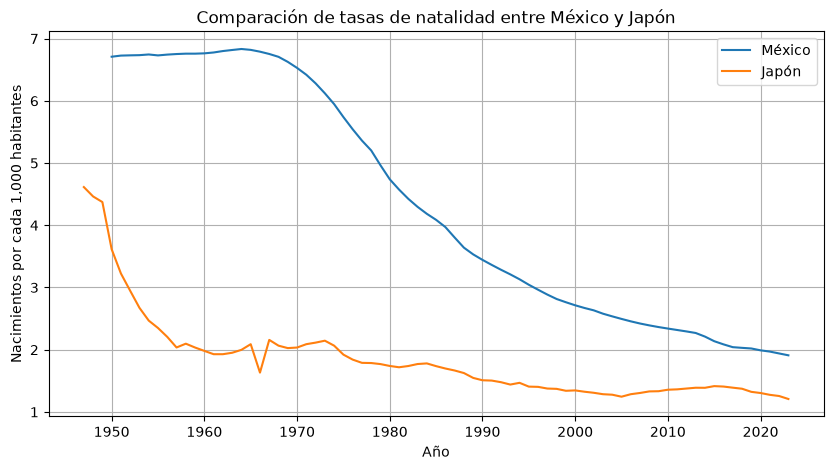

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(anios_mexico, tasa_mexico, label="México")
plt.plot(anios_japon, tasa_japon, label="Japón")

plt.title("Comparación de tasas de natalidad entre México y Japón")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()
plt.show()

## 12 · Combos frecuentes

Patrones repetidos en las tres prácticas, juntos como referencia rápida.

In [35]:
# Filtrar un país + rango de años + columnas de interés
df_pop[
    (df_pop["Entity"] == "Mexico") & (df_pop["Year"] >= 2006) & (df_pop["Year"] <= 2020)
][["Entity", "Year", "Annual change in population"]]

,Entity,Year,Annual change in population
22255,Mexico,2006,1442162.0
22256,Mexico,2007,1520690.0
22257,Mexico,2008,1599930.0
22258,Mexico,2009,1625434.0
22259,Mexico,2010,1624178.0
22260,Mexico,2011,1619605.0
22261,Mexico,2012,1574705.0
22262,Mexico,2013,1525364.0
22263,Mexico,2014,1440693.0
22264,Mexico,2015,1288045.0


In [36]:
# Top 10 por categoría con groupby
(
    df_le.dropna(subset=["code"])
    .groupby("entity")["life_expectancy_0"]
    .mean()
    .sort_values(ascending=True)
    .head(10)
)

entity
USSR                        32.700000
South Sudan                 37.841631
Sierra Leone                43.189605
Mali                        43.760793
Niger                       44.187513
East Timor                  44.684692
Nigeria                     44.855897
Chad                        45.007786
Central African Republic    45.084431
Malawi                      45.554985
Name: life_expectancy_0, dtype: float64

In [37]:
# Comparar dos países: vía NumPy (intersect1d) vs. vía pandas (merge) — mismo resultado, dos caminos
anios_comunes_np = np.intersect1d(anios_mexico, anios_japon)

comparacion_pd = pd.merge(
    mexico_f[["year", "fertility_rate_hist"]],
    japon_f[["year", "fertility_rate_hist"]],
    on="year"
)

print(len(anios_comunes_np), "años en común (NumPy)")
print(len(comparacion_pd), "filas en común (pandas merge)")

74 años en común (NumPy)
74 filas en común (pandas merge)
